<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Total_Population_by_State.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

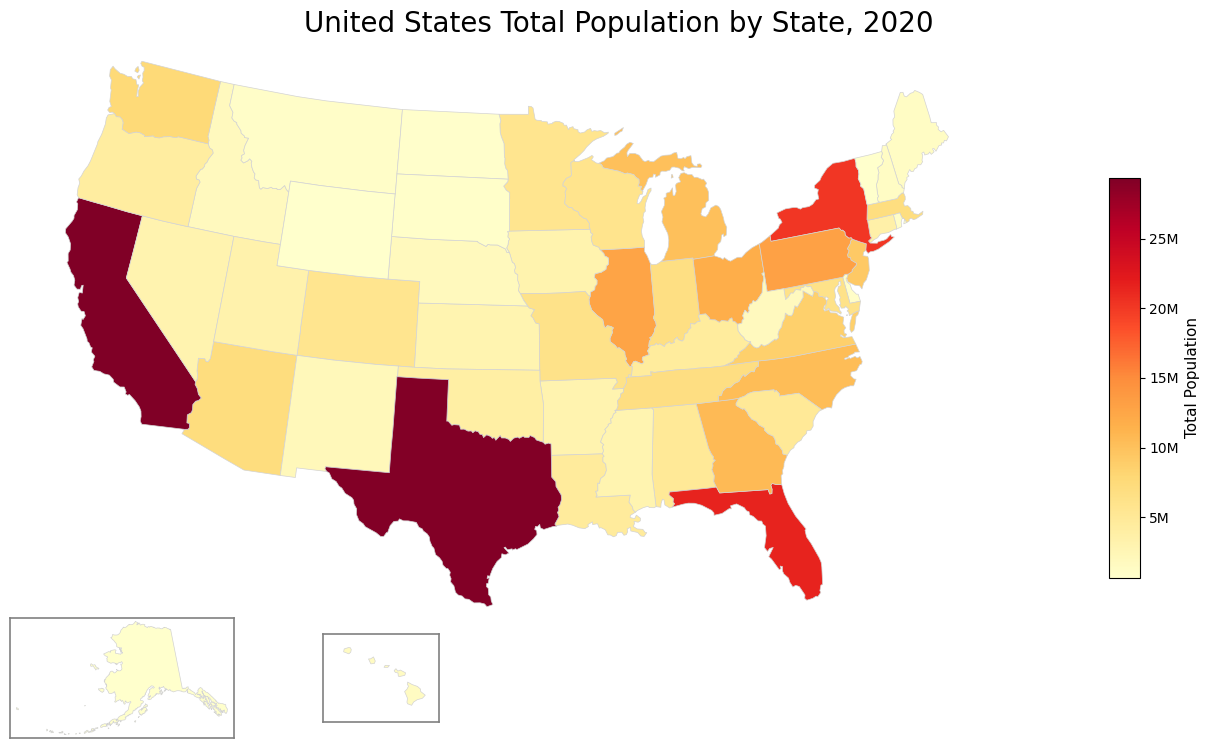

In [2]:
# Run once
# !pip install geopandas pandas numpy matplotlib openpyxl

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

# Read Excel file
file = "/content/DECENNIALCD1182020.P1-2026-06-17T154341.xlsx"

census_data = pd.read_excel(
    file,
    sheet_name="Data",
    header=None
)

# Row 0 has the state names
# Row 1 has the total population values
states = census_data.iloc[0].copy()
population = census_data.iloc[1].copy()

# Turn into DataFrame
pop_df = pd.DataFrame({
    "state": states,
    "population": population
})

# Remove label row
pop_df = pop_df[pop_df["state"] != "Label"].copy()

# Remove territories only
territories = [
    "Puerto Rico",
    "Guam",
    "Virgin Islands",
    "American Samoa",
    "Northern Mariana Islands"
]

pop_df = pop_df[~pop_df["state"].isin(territories)].copy()

# Make population numeric
pop_df["population"] = (
    pop_df["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

pop_df["population"] = pd.to_numeric(
    pop_df["population"],
    errors="coerce"
)

# Read state boundaries
url = "https://raw.githubusercontent.com/python-visualization/folium/master/examples/data/us-states.json"

state_geo = gpd.read_file(url)

# Make sure coordinates are latitude/longitude
state_geo = state_geo.to_crs(epsg=4326)

# Merge state boundaries with population data
merged = state_geo.merge(
    pop_df,
    left_on="name",
    right_on="state",
    how="left"
)

# Remove territories only if they appear in the map file
territory_codes = ["PR", "GU", "VI", "MP", "AS"]
merged = merged[~merged["id"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["id"].isin(["AK", "HI"])].copy()
alaska = merged[merged["id"] == "AK"].copy()
hawaii = merged[merged["id"] == "HI"].copy()

# Color scale
population_values = merged["population"].dropna()
vmin = population_values.quantile(0.02)
vmax = population_values.quantile(0.98)

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main Lower 48 map
ax_main = fig.add_axes([0.02, 0.18, 0.80, 0.75])

lower48_proj.plot(
    column="population",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.5,
    vmin=vmin,
    vmax=vmax,
    ax=ax_main,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.5
    }
)

ax_main.axis("off")

# Alaska inset box
ax_ak = fig.add_axes([0.05, 0.05, 0.19, 0.15])
ax_ak.set_facecolor("white")

alaska_proj.plot(
    column="population",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.5,
    vmin=vmin,
    vmax=vmax,
    ax=ax_ak,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.5
    }
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.03
y_buffer = (maxy - miny) * 0.03

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset box
ax_hi = fig.add_axes([0.28, 0.07, 0.10, 0.11])
ax_hi.set_facecolor("white")

hawaii_proj.plot(
    column="population",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.5,
    vmin=vmin,
    vmax=vmax,
    ax=ax_hi,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.5
    }
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Colorbar
ax_cbar = fig.add_axes([0.85, 0.25, 0.022, 0.50])

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []

cbar = fig.colorbar(sm, cax=ax_cbar)

# Make colorbar numbers easier to read
cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x / 1_000_000:.0f}M")
)

cbar.set_label("Total Population", fontsize=11)

# Title
fig.suptitle(
    "United States Total Population by State, 2020",
    fontsize=20,
    y=0.96
)

plt.show()